In [1]:
import numpy as np
import torch
import torch_geometric as tg
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from torch_geometric import seed_everything

import seaborn as sns
import matplotlib.pyplot as plt


In [8]:
def load_result(file, inductive=False):
    df = pd.read_csv(f'../results/{file}')
    if inductive:
        # rename 'test_cost' as 'cost'
        df = df.rename(columns={'test_cost': 'cost'})
        # conserve only rows where feature_type is node2vec if method in ['NodeGNN', 'LinkGNN']
        df = df[~((df['method'].isin(['NodeGNN', 'LinkGNN'])) & (df['feature_type'] != 'node2vec'))] 
    # rename "GNN" as "NodeGNN"
    df['method'] = df['method'].replace({'GNN': 'NodeGNN', 'kwikcluster': 'KwikCluster', 'modified_pivot': 'ModifiedPivot',})
    # rename AmazonComputers as AmazonPC
    return df



def custom_agg_func(precision, ty):
    # define an aggregation function that returns mean and sem as string with precision decimal places and type (f or e)
    def agg_func(x):
        # return a string with mean and sem
        mean = x.mean()
        sem = x.sem()
        if sem < 10**(-precision):
            return f"{mean:.{precision}{ty}} ± {sem:.0e}"
        return f"{mean:.{precision}{ty}} ± {sem:.{precision}{ty}}"
    return agg_func

def aggregate_df(dataset_df, variables=['cost', 'found_clusters']):
    
    agg_datasets = []
    for var in variables:
        if var == 'NMI':
            agg_func = custom_agg_func(3, 'f')
        elif var == 'runtime':
            agg_func = custom_agg_func(2, 'e')
        else:
            agg_func = custom_agg_func(3, 'f')
        if var == 'cost':
            # first normalize cost by dividing by min cost per dataset
            dataset_df[var] = dataset_df.groupby('name')[var].transform(lambda x: x / x.min())
        # if var=='inference_time', substitute NaN with the 'runtime' column
        if var == 'inference_time':
            dataset_df[var] = dataset_df[var].fillna(dataset_df['runtime'])

        agg_df = dataset_df.groupby(['name', 'method'])[var].agg(agg_func).reset_index()
        agg_df = agg_df.rename(columns={var: 'value'})
        agg_df['metric'] = var
        agg_datasets.append(agg_df)
    agg_df = pd.concat(agg_datasets, ignore_index=True)
    # sort by name and metric
    agg_df['metric'] = pd.Categorical(agg_df['metric'], categories=variables, ordered=True)
    agg_df = agg_df.sort_values(['name', 'metric'])

    # create a new dataframe, with multindex as dataset name and metric, methods as columns
    agg_df = agg_df.pivot(index=['name', 'metric'], columns='method', values='value').reset_index()
    # create multindex columns to avoid repetition on 'name'
    agg_df.set_index(['name', 'metric'], inplace=True)

    return agg_df


def clean_df(full_df, datasets, inductive=False):
    dataset_df = full_df[full_df['name'].isin(datasets)]
    
    dataset_df = dataset_df[~dataset_df['method'].isin(['EMBOnly',])]
    dataset_df = dataset_df[~dataset_df['objective'].isin([ 'MinClustering', 'MinIntraDisagree'])]
    
    if inductive:
        dataset_df['method'].replace({'NodeGNN': 'NodeGNN (I)', 'LinkGNN': 'LinkGNN (I)', 'KwikCluster': 'KwikCluster (T)', 'ModifiedPivot': 'ModifiedPivot (T)', 'LinearLink': 'LinkLinear (I)'}, inplace=True)
        method_order = ['NodeGNN (I)', 'LinkGNN (I)', 'KwikCluster (T)', 'ModifiedPivot (T)']
    else:
        # order datasets according to methods  'NodeGNN', 'LinkGNN', 'KwikCluster', 'ModifiedPivot', 'CFP'
        method_order = ['NodeGNN', 'LinkGNN', 'KwikCluster', 'ModifiedPivot', 'CFP']
    dataset_df['method'] = pd.Categorical(dataset_df['method'], categories=method_order, ordered=True)
    dataset_df = dataset_df.sort_values('method')
    print(dataset_df['method'].unique())
    # do the same for dataset names according to cc_bench_datasets order
    dataset_df['name'] = pd.Categorical(dataset_df['name'], categories=datasets, ordered=True)
    dataset_df = dataset_df.sort_values('name')
    return dataset_df


def plot_cost_results(full_df, title, datasets, ylims=(0.9, 2.1), figsize=(12,6), logscale=False, s=10, inductive=False):

    dataset_df = clean_df(full_df, datasets, inductive=inductive)

    # for each name normalize the cost by dividing by the minimum cost achieved on that dataset by any method
    dataset_df['cost'] = dataset_df.groupby('name')['cost'].transform(lambda x: x / x.min())

    plt.figure(figsize=figsize)
    sns.pointplot(data=dataset_df, x='name', y='cost', hue='method', palette='Set2', linestyle='', dodge=0.5, markers=['o', 's', 'D', 'X', 'P', 'h'], markersize=s, linewidth=s/3, errorbar='se')
    
    plt.xlabel('')
    plt.ylabel('MD cost (normalized by min)')
    if logscale:
        plt.yscale('log')
    plt.ylim(*ylims)
    #plt.yscale('log')
    plt.legend(title='Method')
    plt.grid(True)
    plt.tight_layout()
    #plt.savefig(f'./results/figures/costs_across_{title}.pdf')
    plt.show()
    return
    






def plot_cost_results_inductive(full_df, title, datasets, ylims=[(0.9, 2.1), (7, 1100)], figsize=(12,6), logscale=False, s=10):
    
    dataset_df = clean_df(full_df, datasets, inductive=True)
    dataset_df['run'] = dataset_df.index % 5  # assuming 5 runs per method per dataset
    print(dataset_df.head())

    # for each name normalize the cost by dividing by the minimum cost achieved on that dataset by any method
    

    dataset_df['cost'] = dataset_df.groupby(['name', 'run'])['cost'].transform(lambda x: x / x.min())
    #dataset_df['cost'] = dataset_df.groupby('name')['cost'].transform(lambda x: x / x.min())
    # set seaborn context to paper and font scale to 1.5 and a serif font
    sns.set_context('paper', font_scale=2.3)
    sns.set_style("ticks", {"font.family": "serif", "font.serif": ["Times", "Palatino", "New Century Schoolbook", "Bookman", "Computer Modern Roman"]})

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=figsize)
    fig.subplots_adjust(hspace=0.05)  # adjust space between Axes

    set2_colors = sns.color_palette("colorblind")
    set2_first = set2_colors[0]

    # higher plot: NodeGNN
    sns.pointplot(data=dataset_df[dataset_df['method'] == 'NodeGNN (I)'], x='name', y='cost', linestyle='', marker='o', color=set2_first, markersize=s, linewidth=s/3, errorbar='se', ax=ax1)

    # lower plot: other methods
    sns.pointplot(data=dataset_df, x='name', y='cost', hue='method', palette='colorblind', linestyle='', dodge=0.7, markers=['o', 's', 'D', '^'], markersize=s, linewidth=s/3, errorbar='se', ax=ax2,)

    ax2.set_ylim(*ylims[0])
    ax2.set_xlabel('')
    ax1.set_ylabel('')
    ax2.set_ylabel('')

    fig.supylabel('Approximation Ratio')

    ax2.legend_.remove()
    fig.legend(title='', loc='upper center', bbox_to_anchor=(0.54, 1.03), ncol=4, frameon=False)
    # 
    ax1.grid(True)
    ax2.grid(True)

    # hide the spines between ax and ax2
    ax1.spines.bottom.set_visible(False)
    ax2.spines.top.set_visible(False)
    ax1.xaxis.tick_top()

    ax1.tick_params(labeltop=False)  # don't put tick labels at the top
    ax1.set_ylim(*ylims[1])
    ax2.xaxis.tick_bottom()

    # rotate x labels by 45 degrees and shift them to the right
    plt.setp(ax2.get_xticklabels(), rotation=45)
    

    if logscale:
        ax1.set_yscale('log')

    # Now, let's turn towards the cut-out slanted lines.
    # We create line objects in axes coordinates, in which (0,0), (0,1),
    # (1,0), and (1,1) are the four corners of the Axes.
    # The slanted lines themselves are markers at those locations, such that the
    # lines keep their angle and position, independent of the Axes size or scale
    # Finally, we need to disable clipping.

    d = .5  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1.2, -d), (1.2, d)], markersize=12,
                linestyle="none", color='k', mec='k', mew=3, clip_on=False)
    ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)
    plt.tight_layout()
    #plt.savefig(f'./results/final/figures/costs_across_inductive_{title}.pdf', bbox_inches='tight')
    plt.show()
    return

# Plots and tables 

## GNN vs Gurobi

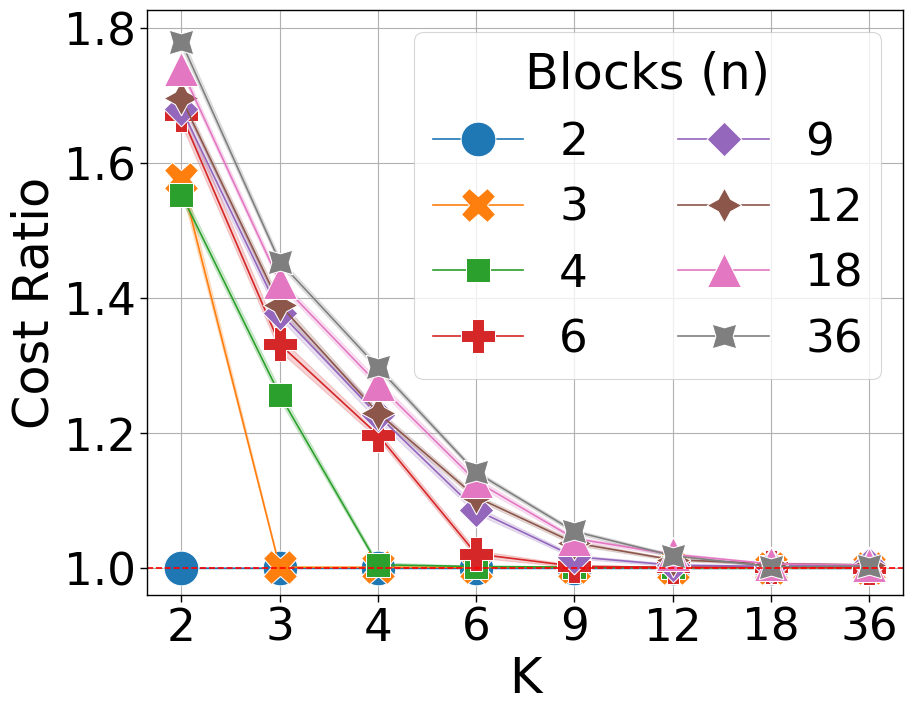

In [150]:
sns.set_context('paper', font_scale=3.7)

# plot at varying out_channels (GNN only, compare with its min)
df = pd.read_csv('../results/gnn_vs_gurobi_results_varying_out_channels.csv')
df_gurobi = pd.read_csv('../results/gnn_vs_gurobi_results_fixed_n.csv')
import seaborn as sns
import matplotlib.pyplot as plt

best_out = df_gurobi[['k', 'num_blocks', 'Gurobi']]
df_plot = df.merge(best_out, on=['k', 'num_blocks'], suffixes=('', '_best'))
df_plot['GNN'] = df_plot['GNN'] / df_plot['Gurobi']

fig = plt.figure(figsize=(10,8))

mapto_out_clusters = {v: i for i, v in enumerate(sorted(df_plot['out_clusters'].unique()))}
df_plot['out_clusters_mapped'] = df_plot['out_clusters'].map(mapto_out_clusters)

full_levels = sorted(df['num_blocks'].unique())
sns.lineplot(
    data=df_plot,
    x='out_clusters_mapped',
    y='GNN',
    hue='num_blocks',
    style='num_blocks',
    hue_order=full_levels,
    dashes=False,
    legend='full',
    markers=True,
    markersize=25,
    palette=sns.color_palette("tab10", n_colors=len(full_levels)),
    errorbar='se'
)

plt.axhline(1., color='red', linestyle='--')
plt.xticks(np.arange(len(df_plot['out_clusters'].unique())), sorted(df_plot['out_clusters'].unique()))
plt.xlabel('K')
#plt.xscale('log')
plt.ylabel('Cost Ratio')

plt.legend(title='Blocks (n)', loc='best', ncol=2)

plt.grid()
plt.tight_layout()
plt.show()
fig.savefig('../results/figures/gnn_vs_gurobi_varying_out_channels.pdf')

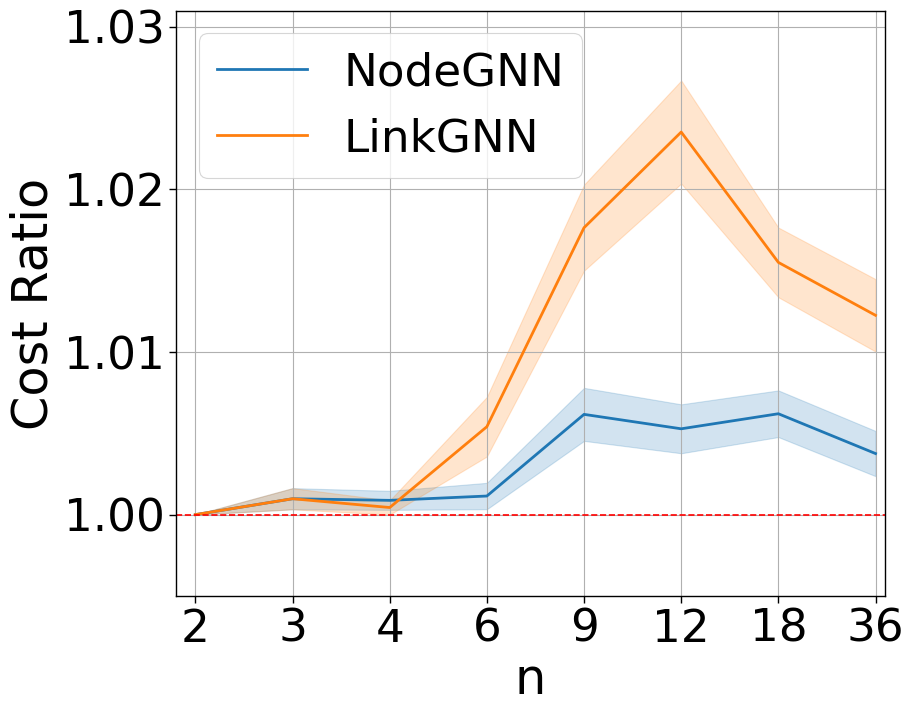

In [151]:
sns.set_context('paper', font_scale=3.7)

df = pd.read_csv('../results/gnn_vs_gurobi_results_fixed_n.csv')
# plot difference between gnn and gurobi
# and between linkgnn and gurobi
import matplotlib.pyplot as plt
import seaborn as sns
df['NodeGNN'] =( df['NodeGNN'])/df['Gurobi']
df['NodeGNN (rounded)'] = (df['GNN_converted'])/df['Gurobi']
#df['LinkGNN'] = (df['LinkGNN'])/df['Gurobi']
df['LinkGNN (rounded)'] = (df['LinkGNN_converted'])/df['Gurobi']
df['KwikCluster'] = (df['KwikCluster'])/df['Gurobi']
df['ModPivot'] = (df['ModPivot'])/df['Gurobi']

df_all = df.melt(id_vars=['num_blocks'], value_vars=['NodeGNN', 'NodeGNN (rounded)', 'LinkGNN', 'LinkGNN (rounded)'])
df_all['rounded'] = df_all['variable'].str.contains('rounded')
df_all['variable'] = df_all['variable'].str.replace(' (rounded)', '', regex=False)
df_all.loc[df_all.variable.isin(['KwikCluster', 'ModPivot']), 'rounded'] = True




# keep only rounded versions
df_all = df_all[df_all['rounded'] == True]

mapto_num_blocks = {v: i for i, v in enumerate(sorted(df_all['num_blocks'].unique()))}
df_all['num_blocks_mapped'] = df_all['num_blocks'].map(mapto_num_blocks)
fig = plt.figure(figsize=(10,8))
sns.lineplot(data=df_all, x='num_blocks_mapped', y='value',  hue='variable', markers=True, linewidth=2, markersize=15,errorbar='se')
plt.axhline(1., color='red', linestyle='--')
# on the x axis use only the num_blocks values present in the data
plt.xticks(np.arange(len(df['num_blocks'].unique())), sorted(df['num_blocks'].unique()))
plt.xlabel('n')
plt.ylabel('Cost Ratio')
#plt.legend(title='Method Comparison')
# remove 'variable' and 'rounded' from legend
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = []
new_handles = []
for label in labels:
    if ' (rounded)' in label:
        new_labels.append(label.replace(' (rounded)', ''))
    elif 'rounded' == label or label == 'variable':
        continue
    elif label == 'True':
        new_labels.append('Rounded')
    elif label == 'False':
        new_labels.append('Relaxed')
    else:
        new_labels.append(label)
    new_handles.append(handles[labels.index(label)])

plt.legend(new_handles, new_labels,  loc='best')
plt.ylim(0.995, 1.031)
plt.xlim(-0.2, 7.1)
plt.grid()
plt.tight_layout()
plt.show()
fig.savefig('../results/figures/all_vs_gurobi.pdf')

## Correlation Clustering Benchmark

In [3]:
full_df = load_result('full_results_transductive.csv')

cc_bench_datasets = ['polblogs', 'ca-GrQc', 'ca-HepTh', 'ca-AstroPh', 'email-Enron', 'cond-mat-2005']

['Linear' 'LinearLink' 'LinkEmbOnly' 'NodeGNN' 'KwikCluster' 'CFP'
 'LinkGNN' 'ModifiedPivot']
['NodeGNN', 'LinkGNN', 'KwikCluster', 'ModifiedPivot', 'CFP', NaN]
Categories (5, object): ['NodeGNN' < 'LinkGNN' < 'KwikCluster' < 'ModifiedPivot' < 'CFP']


/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3138860756.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset_df['cost'] = dataset_df.groupby('name')['cost'].transform(lambda x: x / x.min())


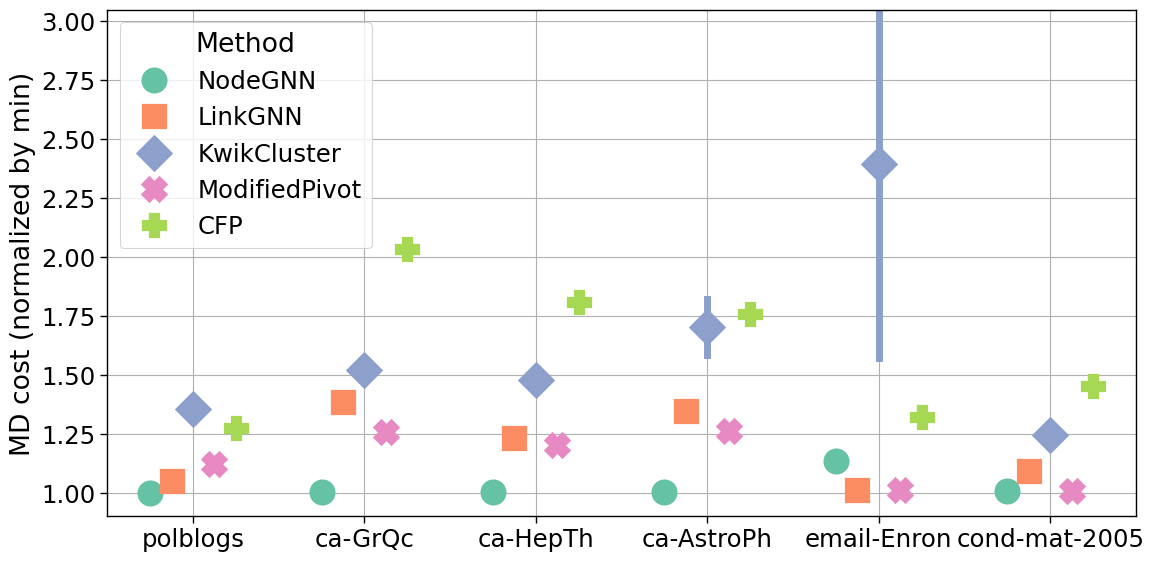

In [4]:
plot_cost_results(full_df, 'cc_bench_datasets', cc_bench_datasets, ylims=(0.9, 3.05), s=15)

In [ ]:
df = clean_df(full_df, cc_bench_datasets)
variables = ['cost',]
agg_df = aggregate_df(df, variables=variables)

# remove metric column
agg_df = agg_df.reset_index().drop(columns=['metric']).set_index('name')

agg_df.to_latex('./results/tables/cc_bench_agg_results.tex')
agg_df

['Linear' 'LinearLink' 'LinkEmbOnly' 'NodeGNN' 'KwikCluster' 'CFP'
 'LinkGNN' 'ModifiedPivot']
['NodeGNN', 'LinkGNN', 'KwikCluster', 'ModifiedPivot', 'CFP', NaN]
Categories (5, object): ['NodeGNN' < 'LinkGNN' < 'KwikCluster' < 'ModifiedPivot' < 'CFP']


/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3138860756.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset_df[var] = dataset_df.groupby('name')[var].transform(lambda x: x / x.min())
/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3138860756.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = dataset_df.groupby(['name', 'method'])[var].agg(agg_func).reset_index()


method,NodeGNN,LinkGNN,KwikCluster,ModifiedPivot,CFP
name,,,,,
polblogs,1.001 ± 3e-04,1.051 ± 0.001,1.358 ± 0.036,1.123 ± 4e-04,1.274 ± 0.002
ca-GrQc,1.005 ± 0.001,1.386 ± 0.004,1.519 ± 0.025,1.259 ± 0.013,2.036 ± 0.005
ca-HepTh,1.003 ± 0.001,1.231 ± 0.002,1.477 ± 0.019,1.205 ± 0.004,1.808 ± 0.002
ca-AstroPh,1.002 ± 7e-04,1.349 ± 7e-04,1.703 ± 0.119,1.263 ± 0.013,1.759 ± 0.002
email-Enron,1.136 ± 0.005,1.012 ± 2e-04,2.396 ± 0.823,1.014 ± 0.004,1.322 ± 8e-04
cond-mat-2005,1.009 ± 0.005,1.094 ± 3e-04,1.247 ± 0.020,1.007 ± 0.003,1.454 ± 7e-04


## Inductive datasets

/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_75249/2932646196.py:67: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset_df['method'].replace({'NodeGNN': 'NodeGNN (I)', 'LinkGNN': 'LinkGNN (I)', 'KwikCluster': 'KwikCluster (T)', 'ModifiedPivot': 'ModifiedPivot (T)', 'LinearLink': 'LinkLinear (I)'}, inplace=True)
/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_75249/2932646196.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. 

['NodeGNN (I)', 'LinkGNN (I)', 'KwikCluster (T)', 'ModifiedPivot (T)']
Categories (4, object): ['NodeGNN (I)' < 'LinkGNN (I)' < 'KwikCluster (T)' < 'ModifiedPivot (T)']
     avg_nodes  avg_edges   name             method  max_clusters  \
384        NaN        NaN  MUTAG  ModifiedPivot (T)         340.0   
382        NaN        NaN  MUTAG  ModifiedPivot (T)         322.0   
0    17.842105  39.684211  MUTAG        LinkGNN (I)           NaN   
380        NaN        NaN  MUTAG  ModifiedPivot (T)         339.0   
377        NaN        NaN  MUTAG    KwikCluster (T)         322.0   

         objective      lr  batch_size  weight_decay  in_channels  ...   cost  \
384    MinDisagree     NaN         NaN           NaN          NaN  ...  272.0   
382    MinDisagree     NaN         NaN           NaN          NaN  ...  248.0   
0    LinkObjective  0.0001        64.0           0.0        128.0  ...  302.0   
380    MinDisagree     NaN         NaN           NaN          NaN  ...  274.0   
377    MinD

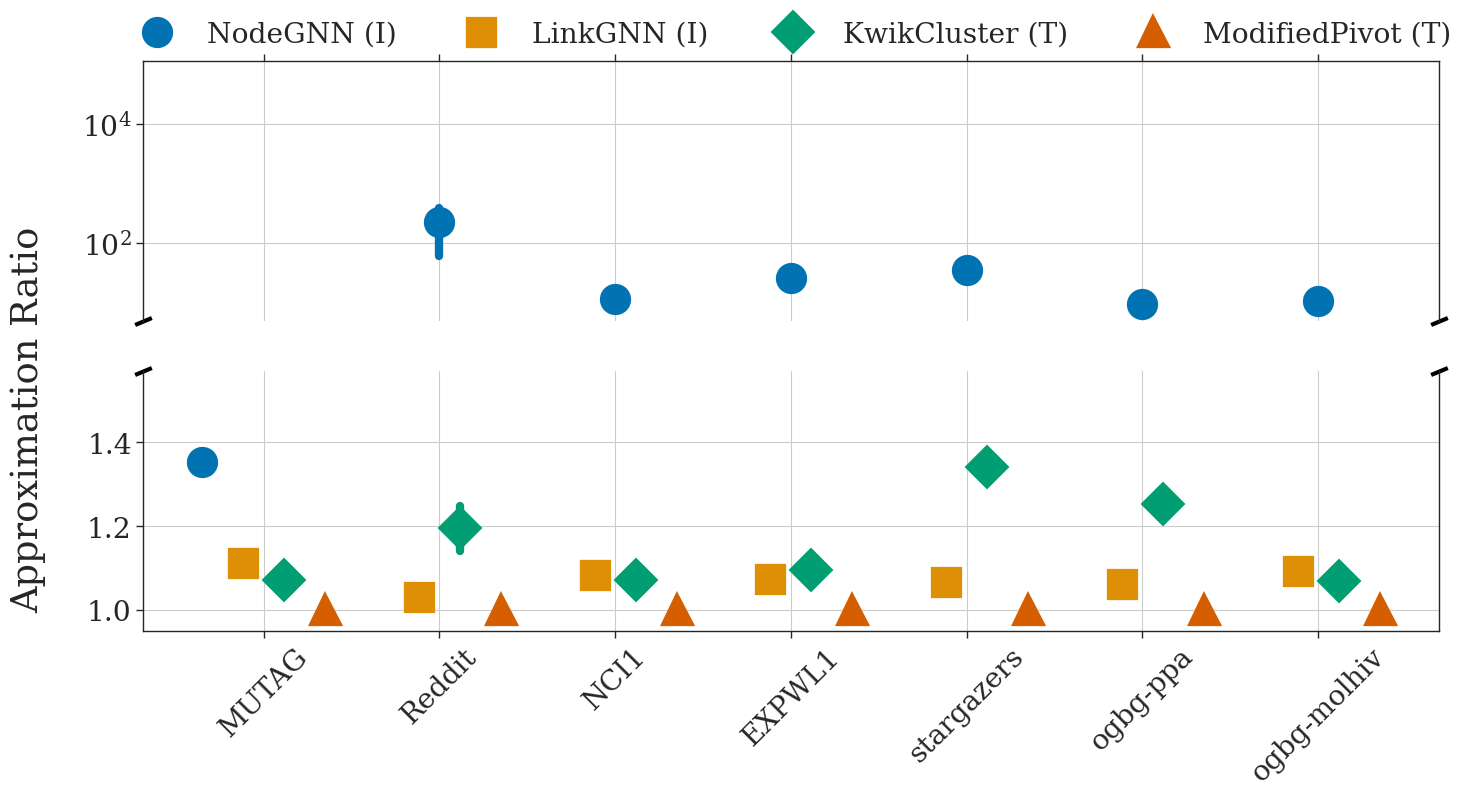

In [9]:
inductive_datasets = ['MUTAG', 'Reddit', 'NCI1', 'EXPWL1',  'stargazers', 'ogbg-ppa', 'ogbg-molhiv']

full_df_inductive = load_result('full_results_inductive.csv', inductive=True)

plot_cost_results_inductive(full_df_inductive, 'inductive_datasets', inductive_datasets, ylims=[(0.95,1.57), (5, 110000)], figsize=(15,8), s=18, logscale=True)
#plot_cost_results(full_df_inductive, 'inductive_feature_datasets', feature_datasets, logscale=True, figsize=(16,8), ylims=(0.8, 1100), s=15, inductive=True)

In [12]:
# create a table where each row is a dataset, and we have two columns: one is the runtime of KwikCluster, and the other is the inference_time of LinkGNN
df_inductive = clean_df(full_df_inductive, inductive_datasets)

agg_func = custom_agg_func(2, 'f')

inductive_runtimes = df_inductive.groupby(['name', 'method'])[["inference_time"]].agg(agg_func).reset_index()
inductive_runtimes = inductive_runtimes[inductive_runtimes['method'].isin(['LinkGNN', 'KwikCluster', 'ModifiedPivot'])]


inductive_runtimes = inductive_runtimes.pivot(index='name', columns='method')
inductive_runtimes.columns = inductive_runtimes.columns.droplevel(0)

#inductive_runtimes = inductive_runtimes.reset_index()
#inductive_runtimes.to_latex('./results/tables/inductive_runtimes.tex')
inductive_runtimes

['NodeGNN', 'LinkGNN', 'KwikCluster', 'ModifiedPivot']
Categories (5, object): ['NodeGNN' < 'LinkGNN' < 'KwikCluster' < 'ModifiedPivot' < 'CFP']


/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_75249/4189095639.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inductive_runtimes = df_inductive.groupby(['name', 'method'])[["inference_time"]].agg(agg_func).reset_index()


method,LinkGNN,KwikCluster,ModifiedPivot
name,,,
MUTAG,0.01 ± 2e-03,0.00 ± 3e-05,0.21 ± 0.07
Reddit,0.02 ± 1e-03,17.98 ± 1.85,633.36 ± 106.97
NCI1,0.04 ± 7e-03,0.08 ± 7e-04,5.70 ± 0.10
EXPWL1,0.02 ± 7e-04,0.36 ± 0.02,11.73 ± 0.09
stargazers,0.09 ± 9e-03,6.37 ± 0.06,314.00 ± 10.96
ogbg-ppa,0.52 ± 0.02,181.54 ± 1.89,2234.55 ± 11.17
ogbg-molhiv,0.20 ± 0.05,0.70 ± 4e-03,46.72 ± 0.31


In [13]:
df_inductive = clean_df(full_df_inductive, inductive_datasets, inductive=True)
#print(df_inductive['method'].unique())
# only use 'NodeGNN', 'LinkGNN', 'KwikCluster'
#df_inductive = df_inductive[df_inductive['method'].isin(['NodeGNN (I)', 'LinkGNN (I)', 'KwikCluster (T)', 'ModifiedPivot (T)', 'LinkLinear (I)'])]

variables = ['cost',]
agg_df = aggregate_df(df_inductive, variables=variables)
agg_df.dropna(inplace=True, axis=1)
# rename methods to 'NodeGNN (I)', 'LinkGNN (I)', 'KwikCluster (T)'
#agg_df = agg_df.rename(columns={'NodeGNN': 'NodeGNN (I)', 'LinkGNN': 'LinkGNN (I)', 'KwikCluster': 'KwikCluster (T)', 'ModifiedPivot': 'ModifiedPivot (T)'})
# remove metric from indexn
agg_df = agg_df.reset_index(level='metric', drop=True)
#agg_df.to_latex('./results/tables/inductive_feature_datasets_agg_results.tex')
agg_df

['NodeGNN (I)', 'LinkGNN (I)', 'KwikCluster (T)', 'ModifiedPivot (T)']
Categories (4, object): ['NodeGNN (I)' < 'LinkGNN (I)' < 'KwikCluster (T)' < 'ModifiedPivot (T)']


/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_75249/2932646196.py:67: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset_df['method'].replace({'NodeGNN': 'NodeGNN (I)', 'LinkGNN': 'LinkGNN (I)', 'KwikCluster': 'KwikCluster (T)', 'ModifiedPivot': 'ModifiedPivot (T)', 'LinearLink': 'LinkLinear (I)'}, inplace=True)
/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_75249/2932646196.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. P

method,NodeGNN (I),LinkGNN (I),KwikCluster (T),ModifiedPivot (T)
name,,,,
MUTAG,1.469 ± 0.034,1.209 ± 0.026,1.165 ± 0.022,1.086 ± 0.026
Reddit,293.235 ± 225.625,1.196 ± 0.080,1.373 ± 0.058,1.159 ± 0.076
NCI1,11.966 ± 0.135,1.095 ± 0.006,1.083 ± 0.005,1.010 ± 0.004
EXPWL1,26.783 ± 0.181,1.089 ± 0.005,1.109 ± 0.004,1.013 ± 0.003
stargazers,39.072 ± 9.357,1.165 ± 0.033,1.463 ± 0.045,1.092 ± 0.031
ogbg-ppa,9.863 ± 0.046,1.079 ± 0.008,1.270 ± 0.006,1.014 ± 0.005
ogbg-molhiv,10.816 ± 0.056,1.102 ± 0.003,1.077 ± 0.003,1.008 ± 0.003


# Architecture Ablation study

In [ ]:

df = load_result('full_results_ablation.csv')


df.conv_type.fillna('No Conv.', inplace=True)
df.num_layers.fillna(0, inplace=True)

df['method'] = df.method.replace({'GNNModel': 'NodeGNN', 'LinkGNNModel': 'LinkGNN'})
df.method.unique()

df['cost'] = df.groupby('name')['cost'].transform(lambda x: x / x.min())


FileNotFoundError: [Errno 2] No such file or directory: 'full_results_ablation.csv'

## GNN only

### Layer comparison

In [ ]:
curr_df = df[ ~df['method'].str.contains('Link')] 
curr_df['method'] = curr_df.apply(lambda row: row['method'] if row['num_layers'] == 0 else str(int(row['num_layers']))+' Layer'+'s'*(row['num_layers']>1), axis=1)

curr_df = curr_df[curr_df.name != 'OGBN-Arxiv']

curr_df = curr_df[curr_df.conv_type.isin(['GCN', 'No Conv.'])]

agg_func = custom_agg_func(2, 'f')
agg_df = curr_df.groupby(['name', 'method'])['cost'].agg(agg_func).reset_index()
conv_order = [ 'EMBOnly', 'Linear', '1 Layer', '2 Layers', '3 Layers']
agg_df['method'] = pd.Categorical(agg_df['method'], categories=conv_order, ordered=True)
agg_df = agg_df.sort_values(['name','method'])
# create a new dataframe, with multindex as dataset name and metric, methods as columns
agg_df = agg_df.pivot(index='name', columns='method', values='cost').reset_index()
# create multindex columns to avoid repetition on 'name'
agg_df.set_index('name', inplace=True)



print(agg_df)
agg_df.to_latex('./results/tables/ablation_node_layers.tex')

/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/2988411301.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curr_df['method'] = curr_df.apply(lambda row: row['method'] if row['num_layers'] == 0 else str(int(row['num_layers']))+' Layer'+'s'*(row['num_layers']>1), axis=1)


method              EMBOnly        Linear       1 Layer      2 Layers  \
name                                                                    
ca-AstroPh     1.65 ± 6e-03  1.64 ± 2e-04  1.00 ± 1e-03   2.16 ± 0.04   
ca-GrQc         2.36 ± 0.24  2.35 ± 2e-03  1.00 ± 6e-04  90.00 ± 9.79   
ca-HepTh        1.74 ± 0.02  1.64 ± 1e-03  1.00 ± 9e-04   3.66 ± 0.18   
cond-mat-2005   1.80 ± 0.01  1.88 ± 1e-03  1.01 ± 5e-03   4.06 ± 0.31   
email-Enron    1.50 ± 2e-03  1.56 ± 2e-03  1.12 ± 5e-03   5.71 ± 2.80   
polblogs        1.06 ± 0.03  1.11 ± 5e-04  1.00 ± 2e-04   3.75 ± 2.38   

method                3 Layers  
name                            
ca-AstroPh     1371.64 ± 0e+00  
ca-GrQc        2224.25 ± 0e+00  
ca-HepTh       2965.73 ± 0e+00  
cond-mat-2005  5643.22 ± 0e+00  
email-Enron    4003.65 ± 0e+00  
polblogs          25.89 ± 4.63  


### Conv comparison

In [ ]:
curr_df = df[ ~df['method'].str.contains('Link')]
curr_df = curr_df[curr_df['conv_type']!= 'No Conv.']
curr_df = curr_df[curr_df['num_layers']==1]
curr_df = curr_df[curr_df.name != 'OGBN-Arxiv']

agg_func = custom_agg_func(2, 'f')
agg_df = curr_df.groupby(['name', 'conv_type'])['cost'].agg(agg_func).reset_index()
conv_order = [ 'GCN', 'GraphSAGE', 'GIN', 'GAT']
agg_df['conv_type'] = pd.Categorical(agg_df['conv_type'], categories=conv_order, ordered=True)
agg_df = agg_df.sort_values(['name','conv_type'])
# create a new dataframe, with multindex as dataset name and metric, methods as columns
agg_df = agg_df.pivot(index='name', columns='conv_type', values='cost').reset_index()
# create multindex columns to avoid repetition on 'name'
agg_df.set_index('name', inplace=True)

print(agg_df)

agg_df.to_latex('./results/tables/ablation_node_conv.tex')


conv_type               GCN     GraphSAGE               GIN          GAT
name                                                                    
ca-AstroPh     1.00 ± 1e-03  1.08 ± 9e-04      42.88 ± 7.06  2.26 ± 0.10
ca-GrQc        1.00 ± 6e-04  1.30 ± 4e-03      30.00 ± 2.99  2.18 ± 0.08
ca-HepTh       1.00 ± 9e-04  1.25 ± 1e-03      55.47 ± 8.22  2.18 ± 0.05
cond-mat-2005  1.01 ± 5e-03  1.33 ± 5e-03  3350.27 ± 583.15  3.01 ± 0.09
email-Enron    1.12 ± 5e-03   7.07 ± 0.87  1056.88 ± 351.45  6.26 ± 0.58
polblogs       1.00 ± 2e-04  1.05 ± 1e-03       1.39 ± 0.05  1.68 ± 0.10


## Link Only

### Layer comparison

In [ ]:
curr_df = df[ df['method'].str.contains('Link')] 
curr_df['method'] = curr_df['method'].replace({'LinkEmbOnly': 'EMBOnly', 'LinearLink': 'Linear'})
curr_df['method'] = curr_df.apply(lambda row: row['method'] if row['num_layers'] == 0 else str(int(row['num_layers']))+' Layer'+'s'*(row['num_layers']>1), axis=1)

curr_df = curr_df[curr_df.name != 'OGBN-Arxiv']

curr_df = curr_df[curr_df.conv_type.isin(['GCN', 'No Conv.'])]

agg_func = custom_agg_func(2, 'f')
agg_df = curr_df.groupby(['name', 'method'])['cost'].agg(agg_func).reset_index()
conv_order = [ 'EMBOnly', 'Linear', '1 Layer', '2 Layers', '3 Layers']
agg_df['method'] = pd.Categorical(agg_df['method'], categories=conv_order, ordered=True)
agg_df = agg_df.sort_values(['name','method'])
# create a new dataframe, with multindex as dataset name and metric, methods as columns
agg_df = agg_df.pivot(index='name', columns='method', values='cost').reset_index()
# create multindex columns to avoid repetition on 'name'
agg_df.set_index('name', inplace=True)




print(agg_df)
agg_df.to_latex('./results/tables/ablation_link_layers.tex')


method              EMBOnly        Linear       1 Layer      2 Layers  \
name                                                                    
ca-AstroPh     1.29 ± 4e-03  1.54 ± 0e+00  1.38 ± 2e-04  1.40 ± 5e-03   
ca-GrQc         1.33 ± 0.03  1.98 ± 3e-03  1.32 ± 1e-03   1.43 ± 0.01   
ca-HepTh        1.40 ± 0.02  1.58 ± 0e+00  1.23 ± 3e-04  1.29 ± 1e-03   
cond-mat-2005  1.23 ± 1e-03  1.27 ± 0e+00  1.05 ± 2e-03  1.11 ± 3e-03   
email-Enron    1.09 ± 1e-04  1.09 ± 1e-06  1.00 ± 2e-04  1.04 ± 4e-04   
polblogs       1.05 ± 1e-05  1.06 ± 8e-04  1.04 ± 7e-04  1.07 ± 3e-03   

method             3 Layers  
name                         
ca-AstroPh     1.37 ± 9e-03  
ca-GrQc         1.46 ± 0.02  
ca-HepTh       1.30 ± 6e-03  
cond-mat-2005   1.12 ± 0.01  
email-Enron     1.14 ± 0.03  
polblogs        1.13 ± 0.01  


/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3136394740.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curr_df['method'] = curr_df['method'].replace({'LinkEmbOnly': 'EMBOnly', 'LinearLink': 'Linear'})
/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_23669/3136394740.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curr_df['method'] = curr_df.apply(lambda row: row['method'] if row['num_layers'] == 0 else str(int(row['num_layers']))+' Layer'+'s'*(row['num_layers']>1), axi

### Conv comparison

In [ ]:
curr_df = df[ df['method'].str.contains('Link')]
curr_df = curr_df[curr_df['conv_type']!= 'No Conv.']
curr_df = curr_df[curr_df['num_layers']==1]

curr_df = curr_df[curr_df.name != 'OGBN-Arxiv']

agg_func = custom_agg_func(2, 'f')
agg_df = curr_df.groupby(['name', 'conv_type'])['cost'].agg(agg_func).reset_index()
conv_order = [ 'GCN', 'GraphSAGE', 'GIN', 'GAT']
agg_df['conv_type'] = pd.Categorical(agg_df['conv_type'], categories=conv_order, ordered=True)
agg_df = agg_df.sort_values(['name','conv_type'])
# create a new dataframe, with multindex as dataset name and metric, methods as columns
agg_df = agg_df.pivot(index='name', columns='conv_type', values='cost').reset_index()
# create multindex columns to avoid repetition on 'name'
agg_df.set_index('name', inplace=True)

print(agg_df)

agg_df.to_latex('./results/tables/ablation_link_conv.tex')


conv_type               GCN     GraphSAGE           GIN           GAT
name                                                                 
ca-AstroPh     1.38 ± 2e-04  1.36 ± 2e-04  1.37 ± 2e-03  1.34 ± 9e-03
ca-GrQc        1.32 ± 1e-03  1.37 ± 4e-03   1.50 ± 0.03  1.31 ± 9e-03
ca-HepTh       1.23 ± 3e-04  1.28 ± 7e-03   1.36 ± 0.01  1.24 ± 3e-03
cond-mat-2005  1.05 ± 2e-03  1.11 ± 5e-03  1.19 ± 4e-03  1.04 ± 1e-03
email-Enron    1.00 ± 2e-04   5.99 ± 0.50   1.12 ± 0.02   1.08 ± 0.01
polblogs       1.04 ± 7e-04  1.06 ± 1e-03  1.06 ± 2e-03  1.08 ± 8e-03


# Algorithm Ablation study

In [23]:

df = pd.read_csv('../results/full_results_ablation_inductive.csv')

variables = ['test_cost', 'train_time', 'inference_time', 'gpu_peak_memory_mb']
agg_datasets = []
for var in variables:
    if var == 'test_cost':
        agg_func = custom_agg_func(1, 'f')
    elif 'time' in var:
        agg_func = custom_agg_func(2, 'f')
    else:
        agg_func = custom_agg_func(0, 'f')
    if var == 'test_cost':
        # first normalize cost by dividing by min cost per dataset
        df[var] = df.groupby(['iter'])[var].transform(lambda x: x / x.min())
    # if var=='inference_time', substitute NaN with the 'runtime' column

    agg_df = df.groupby(['ablation',])[var].agg(agg_func).reset_index()
    agg_df = agg_df.rename(columns={var: 'value'})
    agg_df['metric'] = var
    agg_datasets.append(agg_df)
agg_df = pd.concat(agg_datasets, ignore_index=True)
# sort by name and metric
agg_df['metric'] = pd.Categorical(agg_df['metric'], categories=variables, ordered=True)
agg_df = agg_df.sort_values(['ablation', 'metric'])

# create a new dataframe, with multindex as dataset name and metric, methods as columns
agg_df = agg_df.pivot(index=['ablation'], columns='metric', values='value').reset_index()

agg_df.set_index(['ablation'], inplace=True)
agg_df

metric,test_cost,train_time,inference_time,gpu_peak_memory_mb
ablation,,,,
GAT,1.0 ± 2e-03,186.55 ± 8.56,0.01 ± 1e-04,17750 ± 1090
GIN,1.0 ± 2e-03,186.43 ± 8.61,0.01 ± 1e-04,17751 ± 1091
GraphSAGE,1.0 ± 2e-03,189.17 ± 8.85,0.01 ± 1e-04,17751 ± 1091
allones,1.1 ± 4e-03,196.51 ± 7.03,0.01 ± 1e-04,17224 ± 1091
charikar_complete,1.1 ± 3e-03,196.68 ± 9.07,18.08 ± 1.64,17748 ± 1092
no_normalisation,1.0 ± 2e-03,917.81 ± 18.35,0.01 ± 2e-04,17751 ± 1091
no_pivot_sampling,1.0 ± 7e-04,8165.83 ± 523.37,0.01 ± 2e-04,75709 ± 1287
node2vec,1.0 ± 2e-03,189.52 ± 8.65,0.01 ± 1e-04,17751 ± 1091
pivot_rounding,5.6 ± 0.5,196.17 ± 8.98,5.72 ± 0.26,17748 ± 1092


# Threshold sweep

In [24]:
df = pd.read_csv('../results/threshold_sweep.csv')


variables = ['test_cost']
agg_datasets = []
for var in variables:
    if var == 'NMI':
        agg_func = custom_agg_func(3, 'f')
    elif var == 'runtime':
        agg_func = custom_agg_func(2, 'e')
    else:
        agg_func = custom_agg_func(2, 'f')
    if var == 'test_cost':
        # first normalize cost by dividing by min cost per dataset
        df[var] = df.groupby(['iter'])[var].transform(lambda x: x / x.min())
    # if var=='inference_time', substitute NaN with the 'runtime' column
    if var == 'inference_time':
        df[var] = df[var].fillna(df['runtime'])

    agg_df = df.groupby(['hidden_channels', 'threshold'])[var].agg(agg_func).reset_index()
    agg_df = agg_df.rename(columns={var: 'value'})
    agg_df['metric'] = var
    agg_datasets.append(agg_df)
agg_df = pd.concat(agg_datasets, ignore_index=True)
# sort by name and metric
agg_df['metric'] = pd.Categorical(agg_df['metric'], categories=variables, ordered=True)
agg_df = agg_df.sort_values(['hidden_channels', 'threshold', 'metric'])

# create a new dataframe, with multindex as dataset name and metric, methods as columns
agg_df = agg_df.pivot(index=['hidden_channels'], columns='threshold', values='value').reset_index()
# create multindex columns to avoid repetition on 'name'
agg_df.set_index(['hidden_channels'], inplace=True)


agg_df[[0.25, 0.5, 0.90, 0.95, 1.0]]


threshold,0.25,0.5,0.9,0.95,1.0
hidden_channels,,,,,
16,232.50 ± 22.74,67.18 ± 7.62,1.06 ± 0.02,1.03 ± 8e-03,1.09 ± 9e-03
64,222.51 ± 23.73,61.47 ± 7.63,1.00 ± 2e-03,1.03 ± 9e-03,1.09 ± 9e-03
256,221.53 ± 23.98,61.75 ± 7.86,1.01 ± 5e-03,1.03 ± 9e-03,1.09 ± 9e-03
